# VERIFICATION: Static deflection benchmark: uniform transverse load

A fixed-fixed uniform EB beam of length L under uniform distributed load q has the closed-form midspan deflection:

     $w_{max} = q * L^4 / (384 * EI)$

We rebuild a PURE structural stiffness matrix (no mooring springs, no Morison added mass) using the same Beam3DMatrices function, applying a uniform nodal load vector, solve the static system, and compare.

Test directly: stiffness matrix assembly, boundary condition, partitioning, and the Hermite shape-function integrals.

In [1]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

import scipy.sparse as sps
import scipy.sparse.linalg as spla
from scipy.optimize import brentq
from types import SimpleNamespace
import scipy.integrate as scpi
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid as trapz
import pandas as pd
from scipy.integrate import solve_ivp
from tqdm.auto import tqdm
import scipy 
#import scipy.linalg as scla
from threedellips_morison import Beam3DMatrices, AddMooringSpringsGlobal

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Properties tunnel

In [2]:
E = 40e9 #Pa 40GPa, take this as general value for Youngs modulus for C40/50 see appendix concrete hydraulic structures and offshore structures
G = 12e9 # https://eurocodeapplied.com/design/en1992/concrete-design-properties, shear modulus for this type of concrete

mooring_spacing = 25.0

mass = 266.63e3               # [kg/m]
# rho_c   = 266.63 / 104.6242421   # structural density = m/A_tot [kg/m3] ###############

#Ellipse outer axes
L_tunnel = 27000        # tunnel length [m]
z_tunnel = -27.5
z_tun = -27.5           # tunnel centroid level [m], z=0 at still-water level, positive upward
ao = 14                 #m outer semi-major axis radius
ai = 13                 #m inner semi-major axis radius
bo = 8.5                #m outer semi-minor axis radius
bi = 7.5                #m inner semi-minor axis radius

Atot = 104.6242421 #m2, including inner walls, calculated in excel

# Second moments of area for a hollow ellipse around the horizontal (major) and the vertical (minor) axis 
Iy = 3256.17 #m4, calculated in excel, including inner walls
Iz = 5950.91 #m4, calculated in excel, including inner walls

# Second moment of area for a hollow ellipse around the x-axis axis
Ix = (1/12)*L_tunnel * (2 *bo)**3 

#Polar moment of inertia for torsion, for a hollow ellipse, this is an approximation
J = Iy + Iz ##Unsure about this, if the torsion will deform the object in the yz plane should I thus take the  sum of Iy and Iz?

#radius of gyration for mass moment of inertia  [m^2] (should be * mass, but a function later takes it like this)
Im = ((ao * bo * (ao**2 + bo**2) - ai * bi * (ai**2 + bi**2)) / (4 * (ao * bo - ai * bi)))
# Im = mass * ((ao * bo * (ao**2 + bo**2) - ai * bi * (ai**2 + bi**2)) / (4 * (ao * bo - ai * bi)))

Beam_EIy = E*Iy   # bending about local y-axis, relevant for vertical z-deflection N.m2
Beam_EIz = E*Iz   # bending about local z-axis, relevant for horizontal y-deflection N.m2
Beam_EA = E * Atot                 # [N], wat do you take as A? also inner walls?
Beam_GJ = G * J            # [N.m2]?

# taut lines modelled as spring stiffnesses
ky =0 #2.03e6  # [N/m] horizontal stiffness
kz = 0#10.6e6  # [N/m] vertical stiffness
kyz =0 #0.102e6 # [N/m] coupled vertical and horizontal stiffness
kzy = 0#0.102e6 # [N/m] coupled vertical and horizontal stiffness

## Building elemental & global matrices

In [3]:
Le_target = 25        # target element length == mooring interval [m]
loop_StartTime = time.time()

nEle_tunnel = int(round(L_tunnel / Le_target))
nNode = nEle_tunnel + 1

TunCX = np.linspace(0, L_tunnel, nNode)
TunCY = np.zeros(nNode)
TunCZ = -27.5 * np.ones(nNode) ## notice that its at a depth of 27.5m, so the z coordinate is -27.5m

# Node coordinates
NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]

# Tunnel beam elements
# NodeLeft  NodeRight m    EA        EIy       EIz       GJ        Im
Ele = [[i, i + 1, mass, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Im]
       for i in range(nNode - 1)]

nEle = len(Ele)

print("Number of nodes    =", nNode)
print("Number of elements =", nEle)
print("Element length     =", L_tunnel / nEle, "m")

Number of nodes    = 1081
Number of elements = 1080
Element length     = 25.0 m


# Building a structural K

In [4]:
LDOF = 6
nDof = LDOF * nNode  # 6 dof per node

K = np.zeros((nDof, nDof)) # only the stiffness matrix is nonzero
C = np.zeros((nDof, nDof))
M = np.zeros((nDof, nDof))
Q = np.zeros((nDof, nDof))

for iEle in range(nEle):

    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]

    n1, n2 = int(round(n1)), int(round(n2))

    n1dof = LDOF * n1 + np.arange(LDOF)
    n2dof = LDOF * n2 + np.arange(LDOF)

    # Returns elemental M, C, K, Q, FOR BENCHMARK: ZERO OUT ALL MORISON PARAMETERS
    Me, Ce, Ke, Qe = Beam3DMatrices(
        m         = m,
        EA        = EA,
        EIy       = EIy,
        EIz       = EIz,
        GJ        = GJ,
        Im        = Im,
        NodeCoord = [NodeC[n1], NodeC[n2]],
        ky        = 0,
        kyz       = 0,
        kzy       = 0,
        kz        = 0,
        rho_w     = 0,
        ao        = ao,
        bo        = bo,
        CD_y      = 0,
        CD_z      = 0,
        a_amp     = 0,
        omega     = 0,
        rho_c     = 2500, ###
        A_tot     = Atot
    )

    indexes = np.append(n1dof, n2dof)

    for i in range(2 * LDOF):
        for j in range(2 * LDOF):
            M[indexes[i], indexes[j]] += Me[i, j]
            C[indexes[i], indexes[j]] += Ce[i, j]
            K[indexes[i], indexes[j]] += Ke[i, j] #belangrijke deel
            Q[indexes[i], indexes[j]] += Qe[i, j]


# Boundary conditions

Free DOFs: [   6    7    8 ... 6477 6478 6479]
Prescribed DOFs: [   0    1    2    3    4    5 6480 6481 6482 6483 6484 6485]
Number of free DOFs: 6474


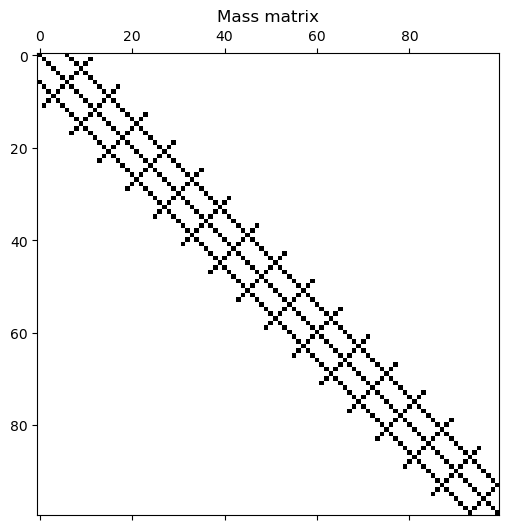

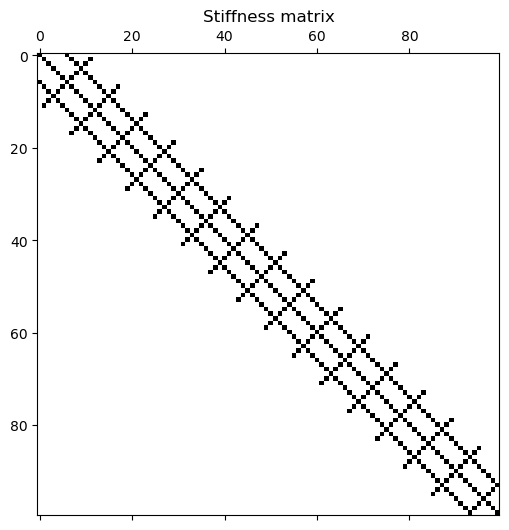

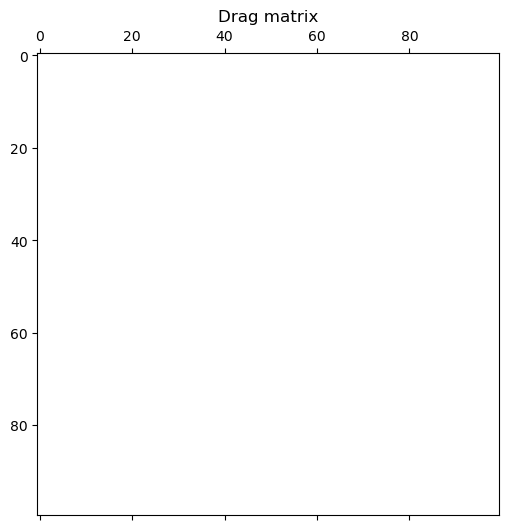

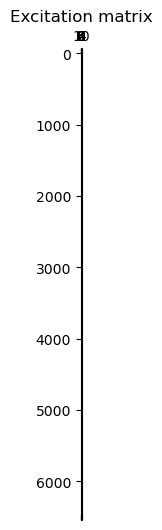

In [5]:
# Boundary conditions: clamp both tunnel ends
NodesClamp = (0, nNode - 1)

# Prescribed DOFs
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0 * LDOF + np.arange(0, LDOF))

# Free DOFs
DofsF = np.setdiff1d(np.arange(nDof), DofsP)
print("Free DOFs:", DofsF)
nDofsF = len(DofsF)

print("Prescribed DOFs:", DofsP)
print("Number of free DOFs:", nDofsF)

# Use direct NumPy slicing instead of list-of-lists.
# This avoids unnecessary Python loops and avoids converting back to arrays later.
ff = np.ix_(DofsF, DofsF)  #creates an indexing object that lets you select a submatrix using specific row indices and specific column indices
fp = np.ix_(DofsF, DofsP)
pf = np.ix_(DofsP, DofsF)
pp = np.ix_(DofsP, DofsP)

M_FF = M[ff]
M_FP = M[fp]
M_PF = M[pf]
M_PP = M[pp]

C_FF = C[ff]
C_FP = C[fp]
C_PF = C[pf]
C_PP = C[pp]

K_FF = K[ff] #Take the full global stiffness matrix K keep only the rows and columns corresponding to free DOFs and discard the clamped DOFs
K_FP = K[fp]
K_PF = K[pf]
K_PP = K[pp]

Q_FF = Q[ff]  # matrix slicing
Q_inertia_FF = Q_FF
Q_drag_FF    = C_FF

plt.figure()
plt.spy(M_FF[:100, :100])
plt.title("Mass matrix")
plt.figure()
plt.spy(K_FF[:100, :100])
plt.title("Stiffness matrix")
plt.figure()
plt.spy(C_FF[:100, :100])
plt.title("Drag matrix")
plt.figure()
plt.spy(Q_FF[:100, :100])
plt.title("Excitation matrix")
plt.spy(M_FP)
pass

# External load vector: horizontal bending

Nodal load vector:
F_v  = q * Le/2   at each end node  (force)
 M_z  = ±q * Le²/12
 
Because the tunnel is uniform and the mesh is regular, we can simply assemble the full nodal load vector element by element.

In [6]:
q_udl = 1 # [N/m] uniform distributed load, for benchmarking only

H_udl, V_udl = np.zeros(nDof), np.zeros(nDof)


#for horizontal bending
for iEle in range(nEle):
    n1, n2 = int(Ele[iEle][0]), int(Ele[iEle][1])
    n1dof = LDOF * n1 + np.arange(LDOF)
    n2dof = LDOF * n2 + np.arange(LDOF)

    H_udl[n1 * LDOF +1] += q_udl * Le_target / 2
    H_udl[n1 * LDOF +5] += q_udl * Le_target**2 / 12
    H_udl[n2 * LDOF +1] += q_udl * Le_target / 2
    H_udl[n2 * LDOF +5] -= q_udl * Le_target**2 / 12

#for horizontal bending
for iEle in range(nEle):
    n1, n2 = int(Ele[iEle][0]), int(Ele[iEle][1])
    n1dof = LDOF * n1 + np.arange(LDOF)
    n2dof = LDOF * n2 + np.arange(LDOF)

    V_udl[n1 * LDOF +2] += q_udl * Le_target / 2
    V_udl[n1 * LDOF +4] += q_udl * Le_target**2 / 12
    V_udl[n2 * LDOF +2] += q_udl * Le_target / 2
    V_udl[n2 * LDOF +4] -= q_udl * Le_target**2 / 12

print(V_udl)
print(H_udl)

# Reduce to free DOFs
H_udl_F = H_udl[DofsF]
V_udl_F = V_udl[DofsF]

print(H_udl_F)
# print(K_FF)

[  0.           0.          12.5        ...   0.         -52.08333333
   0.        ]
[  0.          12.5          0.         ...   0.           0.
 -52.08333333]
[ 0. 25.  0. ...  0.  0.  0.]


In [7]:
print(f"Total assembled horizontal force = {H_udl_F[1::LDOF].sum():.6e} N")
print(f"Expected horizontal force        = {q_udl * L_tunnel:.6e} N")
print(f"Total assembled vertical force   = {V_udl_F[2::LDOF].sum():.6e} N")
print(f"Expected vertical force          = {q_udl * L_tunnel:.6e} N")

Total assembled horizontal force = 2.697500e+04 N
Expected horizontal force        = 2.700000e+04 N
Total assembled vertical force   = 2.697500e+04 N
Expected vertical force          = 2.700000e+04 N


In [8]:
# ── 3. Static solve: K_ver_FF · q_static = F_ver_F ─────────────────────────
q_staticv = scipy.linalg.solve(K_FF, H_udl_F, assume_a='pos')
q_staticw = scipy.linalg.solve(K_FF, V_udl_F, assume_a='pos')


In [9]:
# ── 4. Extract midspan v-displacement ──────────────────────────────────────
# The midspan node is nNode//2; its v-DOF in the global vector is:
mid_node_idx = nNode // 2
dof_v_mid_global = mid_node_idx * LDOF + 1   # global DOF index for v

# Find position of that DOF in the free-DOF list
pos_in_free = np.where(DofsF == dof_v_mid_global)[0]

if len(pos_in_free) == 0:
    raise RuntimeError("Midspan v-DOF is prescribed — check node index or BCs.")

v_mid_fem = q_staticv[pos_in_free[0]]
w_mid_fem = q_staticw[pos_in_free[0]+1]

In [10]:
#Vergeet me nietje
# Fixed-fixed beam, uniform load q, bending stiffness EIz (horizontal bending)
v_mid_analytical = q_udl * L_tunnel**4 / (384.0 * Beam_EIz)
w_mid_analytical = q_udl * L_tunnel**4 / (384.0 * Beam_EIy)

print(f"Midspan v-displacement (FEM)        = {v_mid_fem:.6f} m")
print(f"Midspan w-displacement (FEM)        = {w_mid_fem:.6f} m")
print(f"Midspan v-displacement (analytical) = {v_mid_analytical:.6f} m")
print(f"Midspan w-displacement (analytical) = {w_mid_analytical:.6f} m")

Midspan v-displacement (FEM)        = 5.814074 m
Midspan w-displacement (FEM)        = 10.625695 m
Midspan v-displacement (analytical) = 5.814073 m
Midspan w-displacement (analytical) = 10.625681 m


In [11]:
# ── 6. Report ──────────────────────────────────────────────────────────────
error_pct = 100.0 * abs(v_mid_fem - v_mid_analytical) / abs(v_mid_analytical)

print("  Fixed-fixed EB beam, uniform horizontal load q = 1 N/m")
print(f"  L = {L_tunnel:.0f} m,  EIz = {Beam_EIz:.4e} N·m²")
print(f"  Analytical midspan v = {v_mid_analytical:.6e} m")
print(f"  FEM midspan v        = {v_mid_fem:.6e} m")
print(f"  Relative error       = {error_pct:.5f} %")

  Fixed-fixed EB beam, uniform horizontal load q = 1 N/m
  L = 27000 m,  EIz = 2.3804e+14 N·m²
  Analytical midspan v = 5.814073e+00 m
  FEM midspan v        = 5.814074e+00 m
  Relative error       = 0.00003 %


In [12]:
print( 1*27000**4 / (384.0 * Beam_EIz)) #vergeetmenietje

5.814072711148379


# Modal consistency check

In [13]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)

In [14]:
# Solve generalised eigenvalue problem
eigvals, eigvecs = scipy.linalg.eigh(K_FF, M_FF)
omega_fem = np.sqrt(np.abs(eigvals))  # rad/s
freq_fem = omega_fem / (2*np.pi)

# Analytical fixed-fixed frequencies, beta values (from literature)

In [15]:
# beta_n*L values for fixed-fixed beam
beta_L = np.array([4.73004074, 7.85320462, 10.99560784, 14.13716839, 17.27875953])


In [16]:
# Analytical
omega_anal_z = (beta_L**2) * np.sqrt(Beam_EIz / (mass * L_tunnel**4))
omega_anal_y = (beta_L**2) * np.sqrt(Beam_EIy / (mass * L_tunnel**4))

In [17]:
for n in range(len(beta_L)):
    f_anal = omega_anal_z[n]/(2*np.pi)
    # find FEM frequency nearest to analytical
    idx_near = np.argmin(np.abs(freq_fem - f_anal))
    f_fem = freq_fem[idx_near]
    err = 100*abs(f_fem - f_anal)/f_anal
    print(f"  n={n+1}  betaL={beta_L[n]:.5f}  f_anal={f_anal:.6f} Hz  f_fem={f_fem:.6f} Hz  err={err:.4f}%")

  n=1  betaL=4.73004  f_anal=0.000146 Hz  f_fem=0.000146 Hz  err=0.0013%
  n=2  betaL=7.85320  f_anal=0.000402 Hz  f_fem=0.000402 Hz  err=0.0002%
  n=3  betaL=10.99561  f_anal=0.000789 Hz  f_fem=0.000789 Hz  err=0.0000%
  n=4  betaL=14.13717  f_anal=0.001304 Hz  f_fem=0.001304 Hz  err=0.0001%
  n=5  betaL=17.27876  f_anal=0.001948 Hz  f_fem=0.001948 Hz  err=0.0000%


In [18]:
for n in range(len(beta_L)):
    f_anal = omega_anal_y[n]/(2*np.pi)
    idx_near = np.argmin(np.abs(freq_fem - f_anal))
    f_fem = freq_fem[idx_near]
    err = 100*abs(f_fem - f_anal)/f_anal
    print(f"  n={n+1}  betaL={beta_L[n]:.5f}  f_anal={f_anal:.6f} Hz  f_fem={f_fem:.6f} Hz  err={err:.4f}%")

  n=1  betaL=4.73004  f_anal=0.000108 Hz  f_fem=0.000108 Hz  err=0.0013%
  n=2  betaL=7.85320  f_anal=0.000298 Hz  f_fem=0.000298 Hz  err=0.0002%
  n=3  betaL=10.99561  f_anal=0.000583 Hz  f_fem=0.000583 Hz  err=0.0000%
  n=4  betaL=14.13717  f_anal=0.000964 Hz  f_fem=0.000964 Hz  err=0.0000%
  n=5  betaL=17.27876  f_anal=0.001441 Hz  f_fem=0.001441 Hz  err=0.0000%
